In [1]:
import os
# Limit OpenMP / BLAS / MKL threads early to avoid MKL/OpenBLAS warnings from parallel libs
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
!pip install shap matplotlib scikit-learn joblib threadpoolctl

In [2]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import numpy as np

import matplotlib.pyplot as plt

In [3]:
# Load the test dataset
test_df = pd.read_csv('final_test_scaled_encoded.csv')
X_test = test_df.drop('Risk', axis=1)
y_test = test_df['Risk']

# Load the trained model
model = joblib.load('credit_model.pkl')

In [4]:
# Predict the labels for the test set
y_pred = model.predict(X_test)
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred))

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.57      0.62      0.59        60
           1       0.83      0.80      0.81       140

    accuracy                           0.74       200
   macro avg       0.70      0.71      0.70       200
weighted avg       0.75      0.74      0.75       200



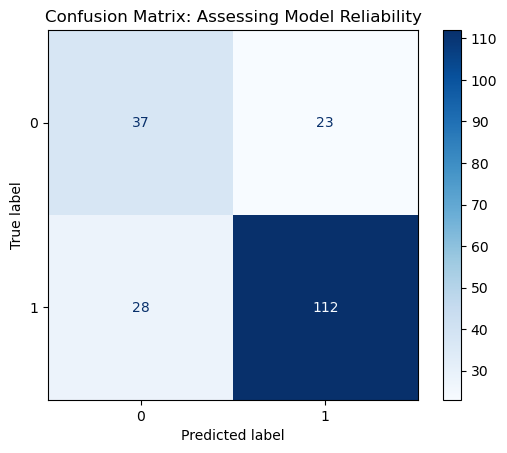

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Assessing Model Reliability")
plt.show()

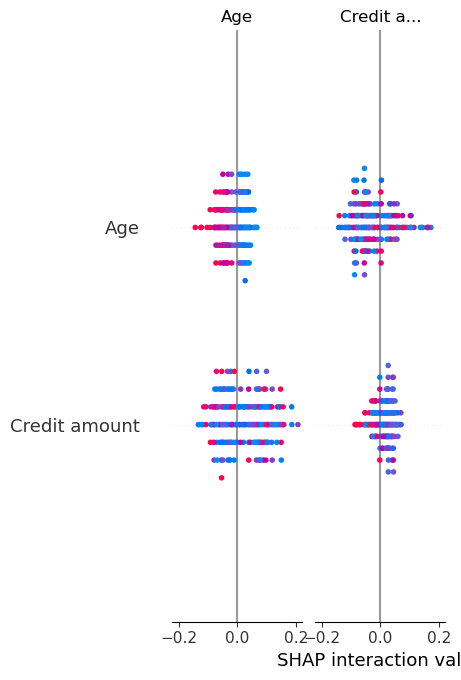

In [6]:
# Ensure the model is loaded in the notebook kernel
if 'model' not in globals():
	import joblib
	model = joblib.load('credit_model.pkl')

# Ensure the test data is available in the kernel
if 'X_test' not in globals():
	# load the same test data used elsewhere in the notebook
	test_df = pd.read_csv('final_test_scaled_encoded.csv')
	X_test = test_df.drop('Risk', axis=1)
	y_test = test_df['Risk']

# Calculate SHAP values for the test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize the SHAP values for the test set
if isinstance(shap_values, list):
	shap.summary_plot(shap_values[1], X_test)
else:
	shap.summary_plot(shap_values, X_test)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
test_df['Customer_Persona'] = kmeans.fit_predict(X_test)

cluster_summary = test_df.groupby('Customer_Persona').mean()
print("\nAverage Metrics per Customer Persona Group:")
print(cluster_summary)


Average Metrics per Customer Persona Group:
                       Age  Credit amount  Duration  Sex_female  Sex_male  \
Customer_Persona                                                            
0                 1.038329      -0.315899 -0.608443    0.210526  0.789474   
1                -0.630398      -0.428183 -0.286628    0.325301  0.674699   
2                 0.113763       1.430096  1.138420    0.350000  0.650000   

                  Housing_free  Housing_own  Housing_rent  \
Customer_Persona                                            
0                     0.070175     0.842105      0.087719   
1                     0.048193     0.650602      0.301205   
2                     0.300000     0.533333      0.166667   

                  Saving accounts_little  Saving accounts_moderate  ...  \
Customer_Persona                                                    ...   
0                               0.596491                  0.070175  ...   
1                               0.6746

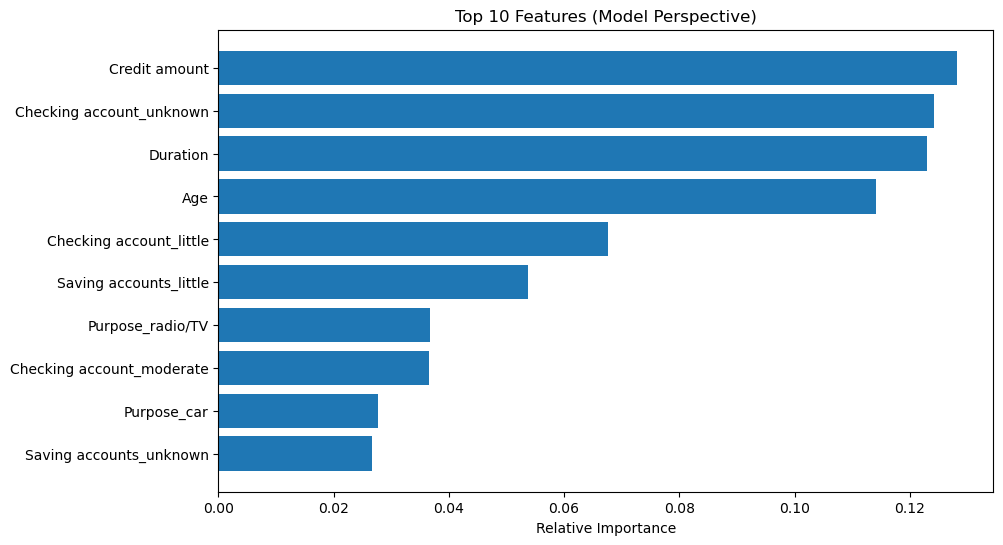

In [8]:
# Get the feature names and their importance from the model
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Features (Model Perspective)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X_test.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [9]:
# Create a dictionary to map the numbers to believable names
persona_map = {
    0: "The Low-Risk Foundation",
    1: "The Aspiring Youth",
    2: "The High-Exposure Group"
}

# Apply the names to a new column
test_df['Persona_Name'] = test_df['Customer_Persona'].map(persona_map)

# Check the results
print(test_df[['Customer_Persona', 'Persona_Name']].head(10))


test_df.to_csv('ai_specialist_final_report.csv', index=False)
print("Final report saved with persona names!")

   Customer_Persona             Persona_Name
0                 0  The Low-Risk Foundation
1                 2  The High-Exposure Group
2                 2  The High-Exposure Group
3                 0  The Low-Risk Foundation
4                 2  The High-Exposure Group
5                 1       The Aspiring Youth
6                 0  The Low-Risk Foundation
7                 0  The Low-Risk Foundation
8                 1       The Aspiring Youth
9                 0  The Low-Risk Foundation
Final report saved with persona names!
